In [13]:
import pandas as pd
import numpy as np
import os
from config import CFG

## Hot reload of py files
%load_ext autoreload
%autoreload 2

# Check the path is correct
print("Contents of DATA_DIR:")
for item in os.listdir(CFG.DATA_DIR):
    print(f"  {item}")

tfrecords_dir = os.path.join(CFG.DATA_DIR, "tfrecords")
print(" TFRECORDS DIR ")
for tffolder in ["test", "train"]:
    tffolder_path = os.path.join(CFG.DATA_DIR, tfrecords_dir)
    if os.path.exists(tffolder_path):
       n_image_tf = len([f for f in os.listdir(tffolder_path)])
       print(f"tfrecords/{tffolder}: {n_image_tf} images")

jpeg_dir = os.path.join(CFG.DATA_DIR, "jpeg")
print("JPEG DIR")
for folder in ["train", "test"]:
    folder_path = os.path.join(jpeg_dir, folder) 
    if os.path.exists(folder_path):
        n_images = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        print(f"  jpeg/{folder}: {n_images} images")
    else:
        print(f"  jpeg/{folder}: NOT FOUND")

dicom_dir = os.path.join(CFG.DATA_DIR, "dicom")
print(" DICOM DIR ")
for dicomfolder in ["test", "train"]:
    dicomfolder_path = os.path.join(dicom_dir, dicomfolder)
    if os.path.exists(folder_path):
       n_image_dicom = len([f for f in os.listdir(dicomfolder_path)])
       print(f"dicom_dir/{dicomfolder}: {n_image_dicom} images")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Contents of DATA_DIR:
  .DS_Store
  test.csv
  dataset.py
  train.csv
  .ipynb_checkpoints
  jpeg
  dicom
  tfrecords
  sample_submission.csv
 TFRECORDS DIR 
JPEG DIR
  jpeg/train: 33126 images
  jpeg/test: 10982 images
 DICOM DIR 
dicom_dir/test: 10982 images
dicom_dir/train: 33126 images


In [14]:
df_train = pd.read_csv(os.path.join(CFG.DATA_DIR, "train.csv"))
print(" F rows length ",len(df_train))
print(" F columns length ",len(df_train.columns))
print(" F columns ", list(df_train.columns))
print()
df_train.head(10)

 F rows length  33126
 F columns length  8
 F columns  ['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']



,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0
5,ISIC_0074311,IP_2950485,female,40.0,lower extremity,unknown,benign,0
6,ISIC_0074542,IP_4698288,male,25.0,lower extremity,unknown,benign,0
7,ISIC_0075663,IP_6017204,female,35.0,torso,unknown,benign,0
8,ISIC_0075914,IP_7622888,male,30.0,torso,unknown,benign,0
9,ISIC_0076262,IP_5075533,female,50.0,lower extremity,unknown,benign,0


In [15]:
print("Target distribution:")
print(df_train['target'].value_counts())
print(f"\nMelanoma rate: {df_train['target'].mean()*100:.2f}%")

print("\n" + "="*50)

print("Beingn malignnent:")
print(df_train["benign_malignant"].value_counts())

print("\n" + "="*50)

print("Missing values per column:")
print(df_train.isnull().sum())


Target distribution:
target
0    32542
1      584
Name: count, dtype: int64

Melanoma rate: 1.76%

Beingn malignnent:
benign_malignant
benign       32542
malignant      584
Name: count, dtype: int64

Missing values per column:
image_name                         0
patient_id                         0
sex                               65
age_approx                        68
anatom_site_general_challenge    527
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64


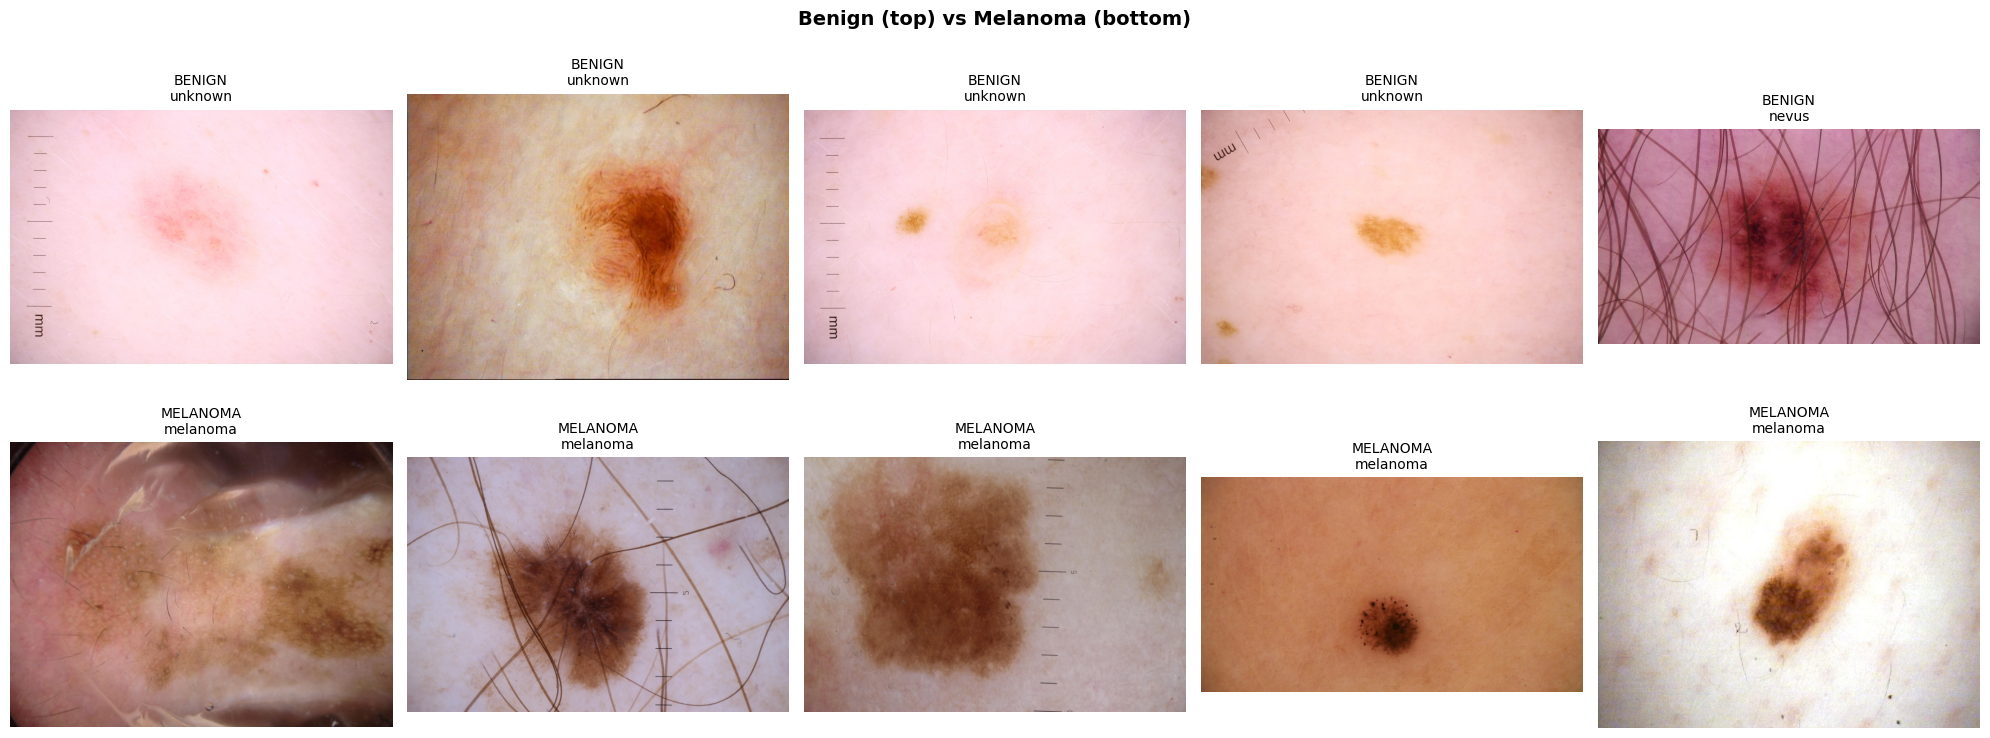

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Benign samples
benign_samples = df_train[df_train['target'] == 0].sample(5, random_state=42)
for i, (_, row) in enumerate(benign_samples.iterrows()):
    img_path = os.path.join(CFG.JPEG_DIR, 'train', f"{row['image_name']}.jpg")
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"BENIGN\n{row['diagnosis']}", fontsize=10)
    axes[0, i].axis('off')

# Melanoma samples
melanoma_samples = df_train[df_train['target'] == 1].sample(5, random_state=42)
for i, (_, row) in enumerate(melanoma_samples.iterrows()):
    img_path = os.path.join(CFG.JPEG_DIR, 'train', f"{row['image_name']}.jpg")
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"MELANOMA\n{row['diagnosis']}", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Benign (top) vs Melanoma (bottom)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
from PIL import Image
import random

# taking 200 to begin with 
sample_images = df_train["image_name"].sample(200, random_state=42)

widths, heights = [], []
for name in sample_images:
    img_path = os.path.join(CFG.JPEG_DIR, 'train', f"{name}.jpg")
    img = Image.open(img_path) 
    widths.append(img.width)
    heights.append(img.height)

print(f"Image widths  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Image heights — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Unique sizes: {len(set(zip(widths, heights)))}")
    

Image widths  — min: 640, max: 6000, mean: 3872
Image heights — min: 480, max: 5184, mean: 2578
Unique sizes: 10


In [19]:
import torch 
import torchvision

print(f"torch version, {torch.__version__}")
print(f"torchvision, {torchvision.__version__}") 
print(f"MPS available:        {torch.backends.mps.is_available()}")
print(f"MPS built:            {torch.backends.mps.is_built()}")

if(torch.backends.mps.is_available()):
    device = torch.device("mps")
elif torch.backends.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device Used:  {device}")

# Test your device 
x = torch.randn(3, 3, device=device)
y = x @ x.T

print(f"\nTest tensor on {device}:\n{y}")
print(f"\n✅ PyTorch + {device} working!")

print(f"torch version, {torch.__version__}")
print(f"torchvision, {torchvision.__version__}") 
print(f"MPS available:        {torch.backends.mps.is_available()}")
print(f"MPS built:            {torch.backends.mps.is_built()}")

if(torch.backends.mps.is_available()):
    device = torch.device("mps")
elif torch.backends.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device Used:  {device}")

# Test your device 
x = torch.randn(3, 3, device=device)
y = x @ x.T

print(f"\nTest tensor on {device}:\n{y}")
print(f"\n✅ PyTorch + {device} working!")

torch version, 2.10.0
torchvision, 0.25.0
MPS available:        True
MPS built:            True
Device Used:  mps

Test tensor on mps:
tensor([[ 0.9823,  1.1719, -0.9405],
        [ 1.1719,  2.4758, -0.7914],
        [-0.9405, -0.7914,  3.9411]], device='mps:0')

✅ PyTorch + mps working!
torch version, 2.10.0
torchvision, 0.25.0
MPS available:        True
MPS built:            True
Device Used:  mps

Test tensor on mps:
tensor([[ 0.1171,  0.0211, -0.4816],
        [ 0.0211,  3.9311, -0.0555],
        [-0.4816, -0.0555,  2.6343]], device='mps:0')

✅ PyTorch + mps working!


In [20]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

df = pd.read_csv(os.path.join(CFG.DATA_DIR, 'train.csv'))
df_train['filepath'] = df_train['image_name'].apply(
    lambda x: os.path.join(CFG.JPEG_DIR, 'train', f'{x}.jpg')
)

for path in df_train['filepath'].head(3):
    assert os.path.exists(path), f"Image not found: {path}"

sgkf = StratifiedGroupKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
df_train['fold'] = -1

for fold_idx, (_, val_idx) in enumerate(
    sgkf.split(df_train, df_train['target'], df_train['patient_id'])
):
    df_train.loc[val_idx, 'fold'] = fold_idx

print("Samples per fold:")
print(df_train['fold'].value_counts().sort_index())
print(f"\nMelanoma per fold:")
print(df_train[df_train['target'] == 1].groupby('fold').size())
print(f"\n✅ Folds created with roughly 6,625 samples per fold with 116-118 melanoma cases in each!")

Samples per fold:
fold
0    6627
1    6625
2    6621
3    6628
4    6625
Name: count, dtype: int64

Melanoma per fold:
fold
0    117
1    116
2    116
3    117
4    118
dtype: int64

✅ Folds created with roughly 6,625 samples per fold with 116-118 melanoma cases in each!


In [21]:
from dataset import MelanomaDataset, get_transforms

# Split train/val for fold 0
df_val = df_train[df_train['fold'] == CFG.FOLD].reset_index(drop=True)
df_trn = df_train[df_train['fold'] != CFG.FOLD].reset_index(drop=True)

# Create datasets
train_dataset = MelanomaDataset(df_trn, transform=get_transforms(CFG.image_size, 'train'))
valid_dataset = MelanomaDataset(df_val, transform=get_transforms(CFG.image_size, 'val'))

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Valid dataset: {len(valid_dataset)} samples")

# Test loading one sample
image, target = train_dataset[0]
print(f"\nImage shape: {image.shape}")   ## (fold 0 is val, folds 1-4 are train) 
print(f"Image dtype: {image.dtype}")     
print(f"Target: {target}")             
print(f"\n✅ Dataset working!")

Train dataset: 26499 samples
Valid dataset: 6627 samples

Image shape: torch.Size([3, 384, 384])
Image dtype: torch.float32
Target: 0

✅ Dataset working!


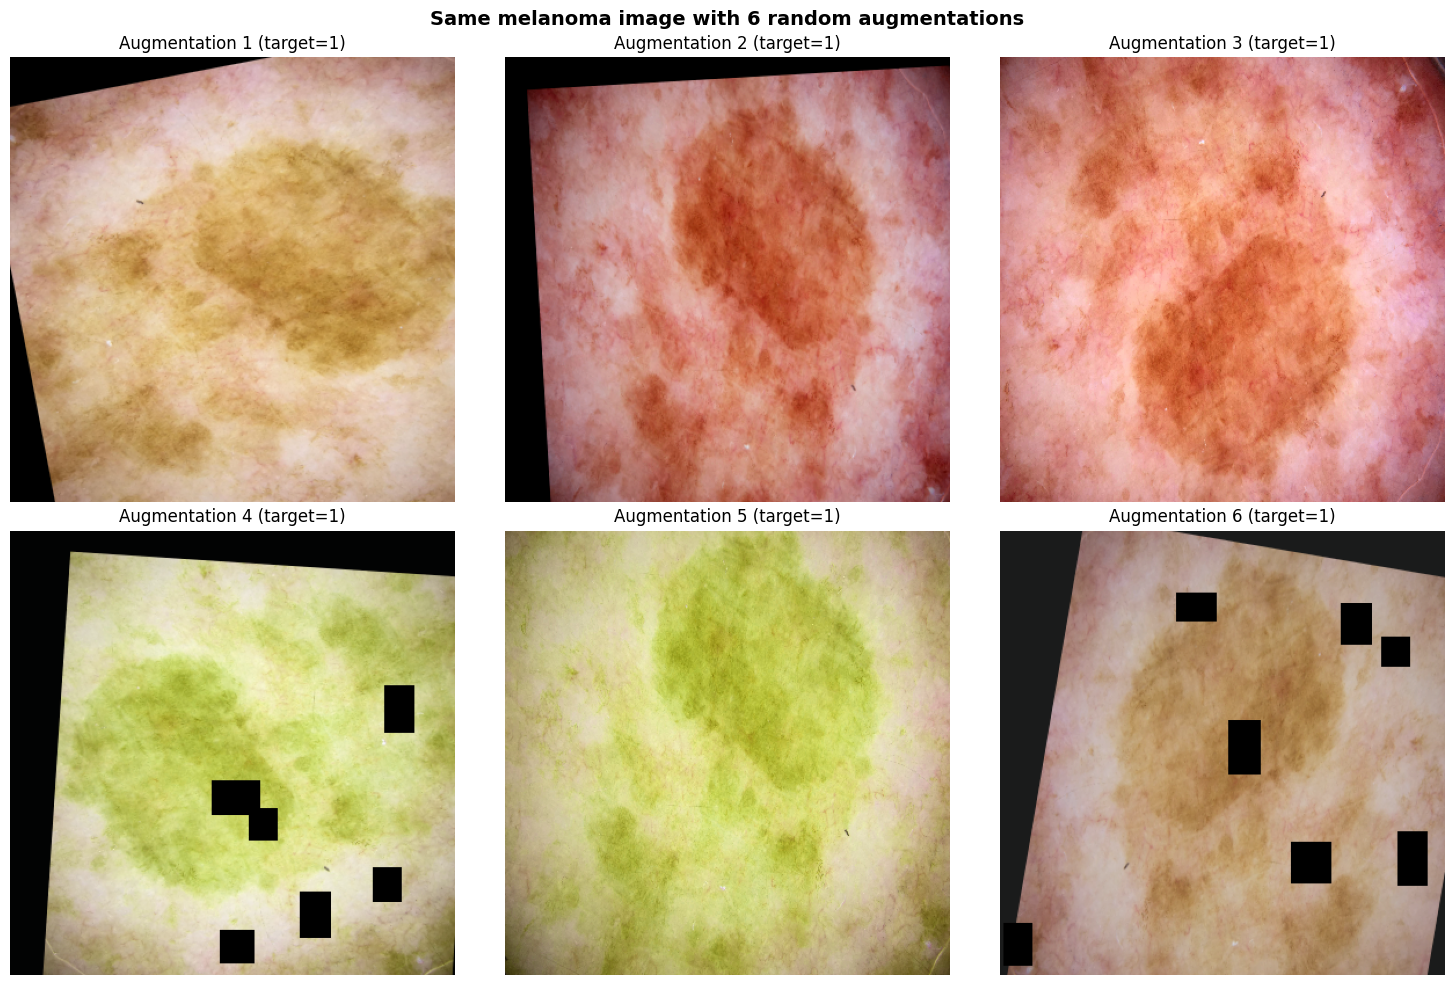

In [22]:
import matplotlib.pyplot as plt

# Grab one melanoma sample to visualise augmentations
mel_idx = df_trn[df_trn['target'] == 1].index[0]
mel_row = df_trn.loc[mel_idx]

# Show the same image with 6 different augmentations applied
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Denormalisation values (to reverse the Normalize transform for display)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(6):
    image, target = train_dataset[mel_idx]
    
    # Convert tensor back to displayable image
    img_np = image.permute(1, 2, 0).numpy()  # CHW -> HWC
    img_np = img_np * std + mean              # Undo normalisation
    img_np = np.clip(img_np, 0, 1)            # Clip to valid range
    
    axes[i].imshow(img_np)
    axes[i].set_title(f"Augmentation {i+1} (target={target.item()})")
    axes[i].axis('off')

plt.suptitle(f"Same melanoma image with 6 random augmentations", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
from models import build_model

# Build the model using settings from config
model = build_model(
    model_name=CFG.model_name,
    out_dim=CFG.out_dim,
    pretrained=CFG.pretrained,
    drop_rate=CFG.drop_rate,
)
model = model.to(CFG.device)

# Count parameters
# Note: if you hit the HF_TOKEN issue it is because we are using anonymous account hence rate-limited. 
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {CFG.model_name}")
print(f"Trainable parameters: {n_params:,}")

# Test forward pass with a dummy batch
dummy_input = torch.randn(2, 3, CFG.image_size, CFG.image_size).to(device)
output = model(dummy_input)

print(f"\nInput shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (logits):\n{output}")

# Convert to probabilities
probs = torch.softmax(output, dim=1)
print(f"\nProbabilities:\n{probs}")
print(f"\nMelanoma probability (class 0):")
print(f"  Sample 1: {probs[0, 0].item():.4f}")
print(f"  Sample 2: {probs[1, 0].item():.4f}")

print(f"\n✅ Model working on {device}!")

Model: deit_small_patch16_224
Trainable parameters: 21,669,129


AssertionError: Input height (384) doesn't match model (224).

In [26]:
from torch.utils.data import DataLoader
from models import build_model
from dataset import MelanomaDataset, get_transforms
from train import train_one_epoch, validate_one_epoch
import torch.nn as nn

# Recreate model with EfficientNet-B4
model = build_model(
    model_name=CFG.model_name,
    out_dim=CFG.out_dim,
    pretrained=CFG.pretrained,
    drop_rate=CFG.drop_rate,
).to(CFG.device)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=True,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=CFG.batch_size * 2,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.init_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.n_epochs, eta_min=CFG.init_lr * 0.01
)

print(f"Model:           {CFG.model_name}")
print(f"Train batches:   {len(train_loader)}")
print(f"Valid batches:   {len(valid_loader)}")
print(f"Device:          {CFG.device}")
print(f"\n✅ Training setup ready!")

Model:           tf_efficientnet_b4.ns_jft_in1k
Train batches:   1656
Valid batches:   208
Device:          mps

✅ Training setup ready!


In [27]:
import time

print(f"Starting 1-epoch sanity check...")
print(f"Train batches: {len(train_loader)} (~{len(train_loader)*CFG.batch_size} samples)")
print(f"Valid batches: {len(valid_loader)}")
print()

t0 = time.time()

# Run one training epoch
train_loss, train_acc = train_one_epoch(
    model, train_loader, optimizer, criterion, CFG.device
)

# Run one validation epoch
val_loss, val_auc = validate_one_epoch(
    model, valid_loader, criterion, CFG.device
)

elapsed = time.time() - t0

print(f"\n{'='*50}")
print(f"  Epoch results (took {elapsed/60:.1f} minutes)")
print(f"{'='*50}")
print(f"  Train Loss: {train_loss:.4f}")
print(f"  Train Acc:  {train_acc:.4f}")
print(f"  Val Loss:   {val_loss:.4f}")
print(f"  Val AUC:    {val_auc:.4f}")
print(f"{'='*50}")

Starting 1-epoch sanity check...
Train batches: 1656 (~26496 samples)
Valid batches: 208



  Train:   0%|                                                                                 | 0/1656 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniforge/base/envs/melanomaClassificationAML/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                                                                                        


  Epoch results (took 33.8 minutes)
  Train Loss: 0.1678
  Train Acc:  0.9732
  Val Loss:   0.0755
  Val AUC:    0.8587
